# EQUITY ASIAN OPTIONS - VALUATION ANALYSIS

Valuation and Risk of Asian-style options. Detailed analysis of different valuation models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from financepy.utils.date import Date
from financepy.utils.day_count import DayCountTypes
from financepy.utils.frequency import FrequencyTypes
from financepy.market.curves.flat_discount_curve import FlatDiscountCurve
from financepy.products.equity.equity_american_option import EquityAmericanOption
from financepy.products.equity.equity_vanilla_option import EquityVanillaOption
from financepy.models.black_scholes import BlackScholes, BlackScholesTypes, OptionTypes
from financepy.products.equity.equity_asian_option import EquityAsianOption
from financepy.products.equity.equity_asian_option import AsianOptionValuationTypes

#############################################################
#  FINANCEPY Version 1.1.2 - Built on 25 Sep 2026 at 14:07  #
#  This software is distributed FREE AND WITHOUT WARRANTY   #
#  Report issues at https://github.com/domokane/FinancePy   #
#############################################################



# Define the Call and Put Options

In [3]:
start_averaging_date = Date(1, 1, 2020)

In [4]:
expiry_dt = Date(1, 1, 2021)

In [5]:
strike_price = 100.0

Assume daily observations

In [6]:
num_observations = int(expiry_dt - start_averaging_date)

In [7]:
asianOption = EquityAsianOption(start_averaging_date,
                                   expiry_dt,
                                   strike_price,
                                   OptionTypes.EUROPEAN_CALL,
                                   num_observations)

In [8]:
print(asianOption)

OBJECT_TYPE: EquityAsianOption
START AVERAGING DATE: 01-JAN-2020
EXPIRY DATE: 01-JAN-2021
STRIKE PRICE: 100.0
OPTION_TYPE: OptionTypes.EUROPEAN_CALL
NUM OBSERVATIONS PER YEAR : 366


## Valuation - Before Averaging Period

In [9]:
value_dt = Date(1,1,2019)

In [10]:
stock_price = 100.0
volatility = 0.20
interest_rate = 0.05
dividend_yield = 0.01

In [11]:
discount_curve = FlatDiscountCurve(value_dt, interest_rate)

In [12]:
dividend_curve = FlatDiscountCurve(value_dt, dividend_yield)

In [13]:
num_observations

366

In [14]:
model = BlackScholes(volatility)
seed = 42
accruedAverage = None

There are a number of valuation approximations to the arithmetic average (AA) option (which does not have an analytical solution)

First we have the Geometric Average (GA) price. This is not the same product of course but the GA is a good approximation for the AA and a LOWER BOUND.

In [15]:
asianOption.value(value_dt, stock_price, discount_curve, dividend_curve, model,
                  AsianOptionValuationTypes.GEOMETRIC, accruedAverage)

np.float64(11.464997136801355)

Then we have Curran's approximation

In [16]:
v_c = asianOption.value(value_dt, stock_price, discount_curve, dividend_curve, model,
                  AsianOptionValuationTypes.CURRAN, accruedAverage)

There is also Turnbull and Wakeman's approximation

In [17]:
asianOption.value(value_dt, stock_price, discount_curve, dividend_curve, model,
                  AsianOptionValuationTypes.TURNBULL_WAKEMAN, accruedAverage)

np.float64(11.681778567208521)

Or we can do it using Monte Carlo

In [18]:
numPaths = 10000

In [19]:
asianOption.value_mc(value_dt, stock_price, discount_curve, dividend_curve, model,
                    numPaths, seed, accruedAverage)

11.60529075663563

Pricing is all clustered around 11.62.

## Convergence Test Before the Averaging Period

In [20]:
num_paths = np.linspace(10000,20000,20)
seed = 1219

In [21]:
values = []
for numPath in num_paths:
    numPath = int(numPath)
    v = asianOption.value_mc(value_dt, stock_price, discount_curve, dividend_curve, model, numPath, seed, accruedAverage)
    values.append(v)

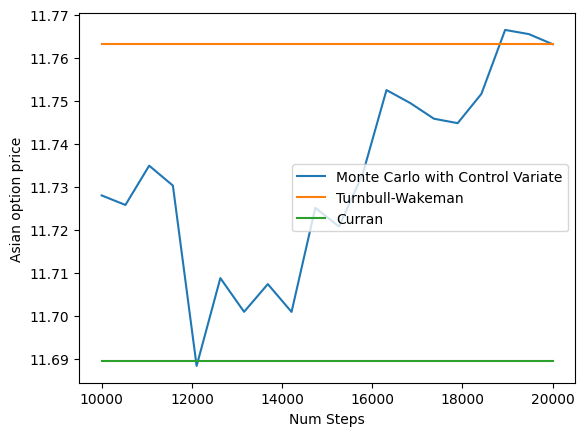

In [22]:
plt.plot(num_paths, values, label="Monte Carlo with Control Variate")
plt.xlabel("Num Steps")
plt.ylabel("Asian option price")
plt.plot(num_paths, [v] * len(num_paths), label = "Turnbull-Wakeman")
plt.plot(num_paths, [v_c] * len(num_paths), label = "Curran")
plt.legend()

Recall that the source of the difference is that the analytical models are unable to exactly match the true arithmetic average distribution. In addition, a smaller effect is that they assume continuous monitoring of the barrier.

## Valuation - In the Averaging Period

Once we are in the averaging period we need to track the average from the start of the averaging period to the value date

In [23]:
value_dt = Date(1, 6, 2020)
discount_curve = FlatDiscountCurve(value_dt, interest_rate)
dividend_curve = FlatDiscountCurve(value_dt, dividend_yield)

The stock price has increased to 105 and the average stock price has been 103.0

In [24]:
stock_price = 105.0
volatility = 0.20
interest_rate = 0.05
dividend_yield = 0.01
accruedAverage = 101.0

The geometric price is once again a LOWER BOUND

In [25]:
asianOption.value(value_dt, stock_price, discount_curve, dividend_curve, model,
                  AsianOptionValuationTypes.GEOMETRIC, accruedAverage)

np.float64(4.519315132243075)

In [26]:
asianOption.value(value_dt, stock_price, discount_curve, dividend_curve, model,
                  AsianOptionValuationTypes.CURRAN, accruedAverage)

np.float64(4.61910335946734)

In [27]:
asianOption.value(value_dt, stock_price, discount_curve, dividend_curve, model,
                  AsianOptionValuationTypes.TURNBULL_WAKEMAN, accruedAverage)

np.float64(4.611161660834233)

In [28]:
asianOption.value_mc(value_dt, stock_price, discount_curve, dividend_curve, model,
                    numPaths, seed, accruedAverage)

4.599847432484079

These are all clustered around 4.59

## Convergence Test In the Averaging Period

In [29]:
num_paths = np.linspace(1000,2000,10)
seed = 1219

In [30]:
values = []
for numPath in num_paths:
    numPath = int(numPath)
    v = asianOption.value_mc(value_dt, stock_price, discount_curve,
                            dividend_curve, model, numPath, seed, accruedAverage)
    values.append(v)

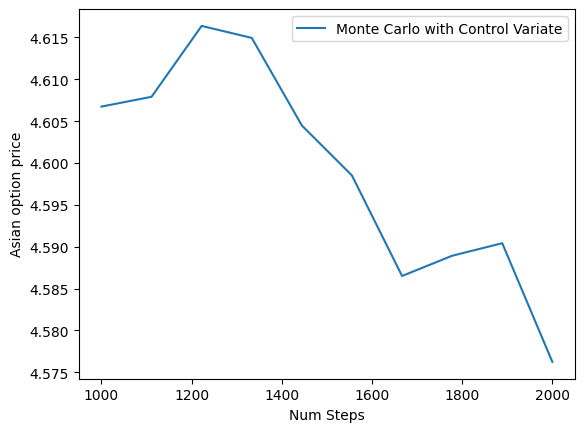

In [31]:
plt.plot(num_paths, values, label="Monte Carlo with Control Variate")
plt.xlabel("Num Steps")
plt.ylabel("Asian option price")
plt.legend()

Recall that the source of the difference is that the analytical models are unable to exactly match the true arithmetic average distribution. In addition, a smaller effect is that they assume continuous monitoring of the barrier. 

Copyright (c) 2020 Dominic O'Kane